In [37]:
import pandas as pd
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt
import numpy as np


# Перша частина
Розрахування до початку А\Б тестування

## Визначемо та проаналізуємо данні

In [13]:
hist = pd.read_csv('ab_test_task_historical_data.csv')


print(hist.shape)
print('-----------')
print(hist.dtypes)
print('-----------')
print(hist.isnull().sum())

(59758, 4)
-----------
id_user                  int64
date_reg                   str
date_first_payment         str
date_spent_15_credits      str
dtype: object
-----------
id_user                      0
date_reg                     0
date_first_payment       56501
date_spent_15_credits    37490
dtype: int64


In [23]:
# Парсимо дати
date_cols = ['date_reg', 'date_first_payment', 'date_spent_15_credits']
for col in date_cols:
    hist[col] = pd.to_datetime(hist[col])

In [20]:
df = pd.read_csv('ab_test_task_data.csv')

# Огляд
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['match'].value_counts())

(125217, 6)
id_user                  int64
date_reg                   str
date_first_payment         str
date_spent_15_credits      str
date_reminder              str
match                    int64
dtype: object
id_user                       0
date_reg                      0
date_first_payment       117980
date_spent_15_credits     73664
date_reminder            110009
match                         0
dtype: int64
match
1    62649
0    62568
Name: count, dtype: int64


In [21]:
# Парсимо дати
date_cols = ['date_reg', 'date_spent_15_credits', 'date_first_payment', 'date_reminder']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

## Порахуємо конверсію до оплат

In [24]:
p_baseline = hist['date_first_payment'].notna().sum() / len(hist)
print(f'Baseline conversion rate: {p_baseline:.4f}')

Baseline conversion rate: 0.0545


## MDE
Означимо мінімальне покращення на 10% і визначемо скільки 

In [25]:
p_test = p_baseline * 1.10
print(p_test)

0.05995347903209613


## Визначемо розмір тестової когорти

In [26]:
effect_size = proportion_effectsize(p_baseline, p_test)

analysis = NormalIndPower()
n_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    ratio=1.0
)

print(f'Потрібно юзерів на групу: {n_per_group:.0f}')
print(f'Всього юзерів: {n_per_group * 2:.0f}')

Потрібно юзерів на групу: 28495
Всього юзерів: 56991


In [27]:
hist['date_reg'] = pd.to_datetime(hist['date_reg'])

daily_regs = hist.groupby(hist['date_reg'].dt.date)['id_user'].count()
avg_daily_regs = daily_regs.mean()

days_needed = (n_per_group * 2) / avg_daily_regs
print(f'Середня кількість реєстрацій на день: {avg_daily_regs:.1f}')
print(f'Потрібно днів: {days_needed:.1f}')

Середня кількість реєстрацій на день: 6639.8
Потрібно днів: 8.6


# Друга частина
Оцінка результату тесту

## Перевіримо розподіл груп

In [29]:
n_control = (df['match'] == 0).sum()
n_test    = (df['match'] == 1).sum()
total     = len(df)
expected  = total / 2

stat, p_srm = chisquare(f_obs=[n_control, n_test], f_exp=[expected, expected])

print(f'Control: {n_control}, Test: {n_test}')
print(f'Chi-square p-value: {p_srm:.4f}')

if p_srm < 0.05:
    print('⚠️ SRM виявлено! Результатам тесту не можна довіряти.')
else:
    print('✅ Сплит коректний.')

Control: 62568, Test: 62649
Chi-square p-value: 0.8189
✅ Сплит коректний.


## Конверсія на першу оплату

In [30]:
groups = df.groupby('match').agg(
    total=('id_user', 'count'),
    converted=('date_first_payment', lambda x: x.notna().sum())
).reset_index()

groups['conversion_rate'] = groups['converted'] / groups['total']
print(groups)

   match  total  converted  conversion_rate
0      0  62568       3506         0.056035
1      1  62649       3731         0.059554


## Перевірка значущості

In [ ]:
converted_control = groups.loc[groups['match'] == 0, 'converted'].values[0]
converted_test    = groups.loc[groups['match'] == 1, 'converted'].values[0]
total_control     = groups.loc[groups['match'] == 0, 'total'].values[0]
total_test        = groups.loc[groups['match'] == 1, 'total'].values[0]

count = [converted_test, converted_control]
nobs  = [total_test, total_control]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f'Z-statistic: {stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('✅ Ефект статистично значущий.')
else:
    print('❌ Недостатньо доказів ефекту.')

Z-statistic: 2.6681
P-value: 0.0038
✅ Ефект статистично значущий.


In [35]:
conv_control = converted_control / total_control
conv_test    = converted_test    / total_test

# 95% CI для кожної групи
ci_control = proportion_confint(converted_control, total_control, alpha=0.05, method='wilson')
ci_test    = proportion_confint(converted_test,    total_test,    alpha=0.05, method='wilson')

uplift = (conv_test - conv_control) / conv_control

print(f'Control: {conv_control:.4f} (95% CI: {ci_control[0]:.4f} – {ci_control[1]:.4f})')
print(f'Test:    {conv_test:.4f} (95% CI: {ci_test[0]:.4f} – {ci_test[1]:.4f})')
print(f'Відносний uplift: {uplift:.2%}')

Control: 0.0560 (95% CI: 0.0543 – 0.0579)
Test:    0.0596 (95% CI: 0.0577 – 0.0614)
Відносний uplift: 6.28%


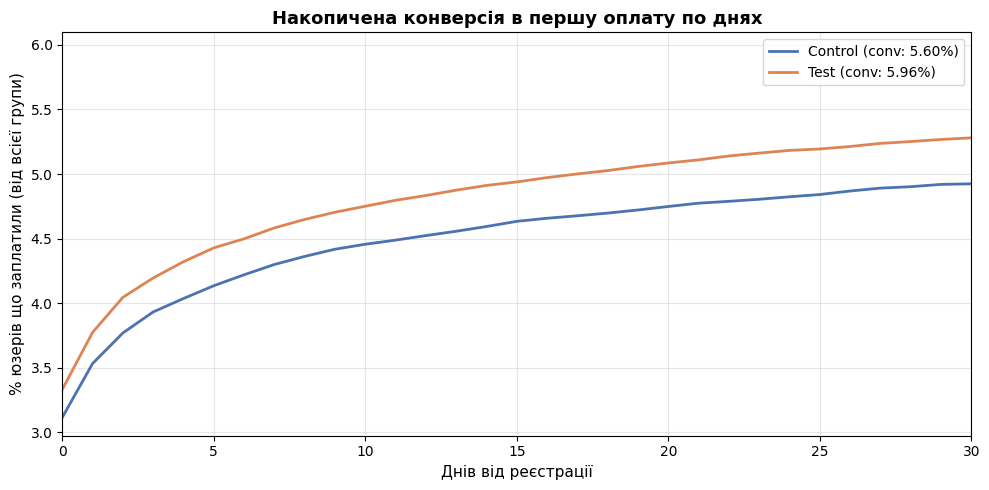

In [41]:
df['days_to_payment'] = (df['date_first_payment'] - df['date_reg']).dt.days

fig, ax = plt.subplots(figsize=(10, 5))
colors = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: f'Control (conv: {conv_control:.2%})', 1: f'Test (conv: {conv_test:.2%})'}

for group in [0, 1]:
    total = (df['match'] == group).sum()
    subset = df[(df['match'] == group) & df['days_to_payment'].notna()]
    
    # Скільки юзерів з усієї групи заплатили до дня X
    day_counts = subset.groupby('days_to_payment')['id_user'].count().sort_index()
    cumulative = day_counts.cumsum() / total * 100  # у відсотках від всієї групи
    
    ax.plot(cumulative.index, cumulative.values,
            label=labels[group], linewidth=2, color=colors[group])

ax.set_xlim(0, 30)
ax.set_xlabel('Днів від реєстрації', fontsize=11)
ax.set_ylabel('% юзерів що заплатили (від всієї групи)', fontsize=11)
ax.set_title('Накопичена конверсія в першу оплату по днях', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
reminded_paid = df[
    (df['match'] == 1) &
    df['date_reminder'].notna() &
    df['date_first_payment'].notna()
].copy()

reminded_paid['days_after_reminder'] = (
    reminded_paid['date_first_payment'] - reminded_paid['date_reminder']
).dt.days

# Скільки заплатили протягом 3 днів після нагадування
within_3d = (reminded_paid['days_after_reminder'] <= 3).sum()
total_reminded_paid = len(reminded_paid)

print(f'Заплатили після нагадування: {total_reminded_paid}')
print(f'З них — протягом 3 днів: {within_3d} ({within_3d/total_reminded_paid:.1%})')
print(reminded_paid['days_after_reminder'].describe())

Заплатили після нагадування: 2430
З них — протягом 3 днів: 2002 (82.4%)
count    2430.000000
mean        5.020165
std        28.842027
min       -39.000000
25%        -1.000000
50%         0.000000
75%         0.000000
max       266.000000
Name: days_after_reminder, dtype: float64
